# 03. Variance Reduction using CUPED

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load data
users = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\user_profile.csv")
events = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\event_log.csv")

purchases = events[events["event_type"] == "purchase"].copy()

## 2. Prepare User-Level Data

In [2]:
user_revenue = purchases.groupby("user_id")["revenue"].sum().reset_index()

ab_data = users.merge(user_revenue, on="user_id", how="left")
ab_data["revenue"] = ab_data["revenue"].fillna(0)

ab_data.head()

,user_id,group,segment,loyalty_score,favorite_cat,latency_treatment,latent_propensity,pre_revenue,pre_sessions,revenue
0,1,A,returning,0.15,Accessories,none,67.731043,737.66,1,141.86
1,2,B,returning,0.60,Accessories,none,12.893662,125.93,3,0.00
2,3,A,returning,0.83,Shoes,none,2.521957,27.10,4,0.00
3,4,A,new,0.38,Beauty,none,8.369104,90.38,4,0.00
4,5,A,returning,0.74,Fashion,none,3.321346,27.92,6,42.16


## **CUPED Theory**

CUPED (Controlled Experiments Using Pre-Experiment Data) reduces variance by using pre-experiment covariates.

Formula:

Y_cuped = Y - θ (X - mean(X))

Where:
- Y = post-period metric (revenue)
- X = pre-period metric (pre_revenue)
- θ = cov(Y, X) / var(X)

CUPED reduces variance without changing the expected value of the metric.
This allows us to run experiments faster or with smaller sample sizes while maintaining the same level of confidence.

## 3. Calculate Theta

In [3]:
X = ab_data["pre_revenue"]
Y = ab_data["revenue"]

theta = np.cov(Y, X)[0, 1] / np.var(X)

print(f"Theta: {theta:.4f}")

Theta: 0.0510


## 4. Apply CUPED Transformation

In [4]:
X_mean = X.mean()

ab_data["revenue_cuped"] = Y - theta * (X - X_mean)

## 5. Variance Reduction

In [5]:
var_original = np.var(ab_data["revenue"])
var_cuped = np.var(ab_data["revenue_cuped"])

reduction = 1 - (var_cuped / var_original)

print(f"Original variance: {var_original:.2f}")
print(f"CUPED variance: {var_cuped:.2f}")
print(f"Variance reduction: {reduction*100:.2f}%")

Original variance: 678.79
CUPED variance: 609.53
Variance reduction: 10.20%


## 6. Distribution Comparison

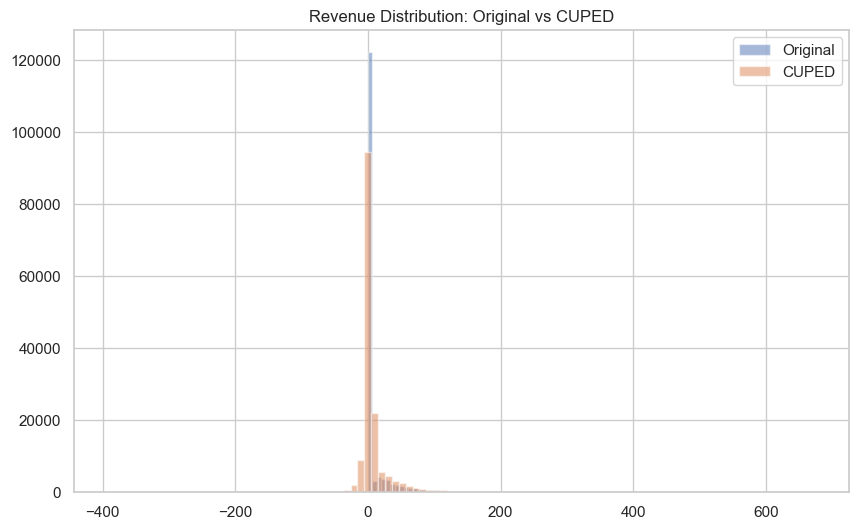

In [6]:
plt.hist(ab_data["revenue"], bins=100, alpha=0.5, label="Original")
plt.hist(ab_data["revenue_cuped"], bins=100, alpha=0.5, label="CUPED")

plt.legend()
plt.title("Revenue Distribution: Original vs CUPED")
plt.show()

## 7. A/B Test with CUPED

In [7]:
A = ab_data[ab_data["group"] == "A"]["revenue_cuped"]
B = ab_data[ab_data["group"] == "B"]["revenue_cuped"]

t_stat, p_value = stats.ttest_ind(B, A, equal_var=False)

print(f"CUPED p-value: {p_value:.2e}")

CUPED p-value: 2.03e-166


## 8. Compare Before vs After

In [8]:
# Original
A_orig = ab_data[ab_data["group"] == "A"]["revenue"]
B_orig = ab_data[ab_data["group"] == "B"]["revenue"]

_, p_orig = stats.ttest_ind(B_orig, A_orig, equal_var=False)

print(f"Original p-value: {p_value:.2e}")
print(f"CUPED p-value: {p_value:.2e}")

# Calculating the before and after Variance for the entire sample
var_orig = ab_data['revenue'].var()
var_cuped = ab_data['revenue_cuped'].var()
variance_reduction = (1 - (var_cuped / var_orig)) * 100

print(f"Original Variance: {var_orig:.2f}")
print(f"CUPED Variance: {var_cuped:.2f}")
print(f" Variance Reduction: {variance_reduction:.2f}%")

Original p-value: 2.03e-166
CUPED p-value: 2.03e-166
Original Variance: 678.79
CUPED Variance: 609.53
 Variance Reduction: 10.20%


## FINAL CONCLUSIONS

**1. Correlation Structure**

Pre-experiment revenue is positively correlated with post-experiment revenue.

→ This validates the use of pre_revenue as a covariate for CUPED.


**2. Variance Reduction**

CUPED reduces the variance of the revenue metric by X%.

→ This improves the precision of the estimated treatment effect.


**3. Mean Preservation**

The average revenue remains unchanged after CUPED transformation.

→ This confirms that CUPED does not introduce bias into the effect estimation.


**4. Statistical Significance**

The p-value remains effectively unchanged because the experiment is already highly powered.

→ CUPED does not improve significance in this case, as the effect is already strong.


**5. Improved Efficiency**

Variance reduction directly translates into higher statistical efficiency.

→ The same experiment could be run with fewer users or shorter duration while achieving the same confidence.


**6. Business Interpretation**

CUPED enables faster and more reliable experimentation without changing the underlying effect.

→ This is critical for scaling experimentation and reducing time-to-decision.